In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Words
words = ["I", "really", "love", "deep", "neural", "network", "learning"]

# Attention Matrix (7x7)
attention = np.array([
    [0.05, 0.10, 0.20, 0.20, 0.15, 0.10, 0.20],
    [0.10, 0.10, 0.20, 0.20, 0.15, 0.10, 0.15],
    [0.05, 0.10, 0.15, 0.25, 0.20, 0.10, 0.15],
    [0.05, 0.10, 0.10, 0.20, 0.25, 0.15, 0.15],
    [0.05, 0.10, 0.10, 0.20, 0.20, 0.20, 0.15],
    [0.05, 0.10, 0.10, 0.15, 0.20, 0.25, 0.15],
    [0.05, 0.10, 0.10, 0.20, 0.15, 0.15, 0.25]
])

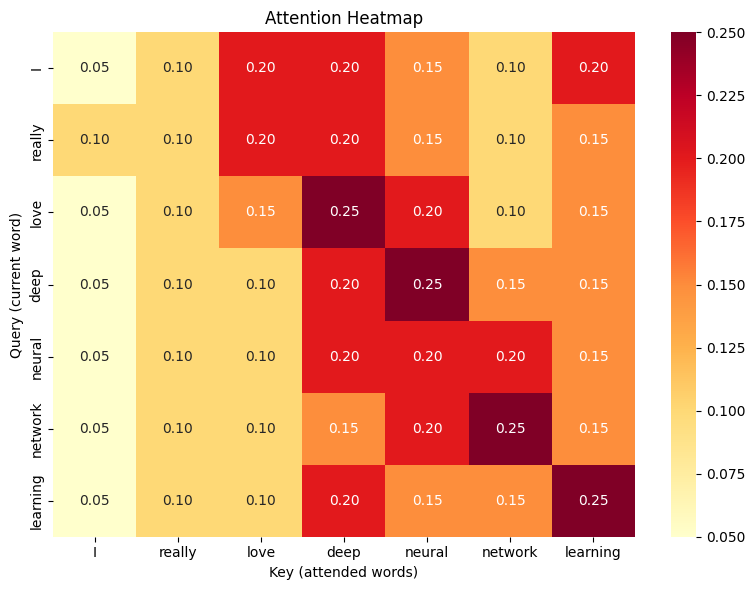

In [2]:
# Normalize rows (ensures sum = 1)
row_sums = attention.sum(axis=1, keepdims=True)
attention = attention / row_sums

# Heatmap Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    attention,
    xticklabels=words,
    yticklabels=words,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)
plt.title("Attention Heatmap")
plt.xlabel("Key (attended words)")
plt.ylabel("Query (current word)")
plt.tight_layout()
plt.show()

In [3]:
# Most attended word per query
print("Most important attention connections:\n")
for i, query_word in enumerate(words):
    max_index = np.argmax(attention[i])
    print(f"{query_word} → {words[max_index]} ({attention[i, max_index]:.2f})")

Most important attention connections:

I → love (0.20)
really → love (0.20)
love → deep (0.25)
deep → neural (0.25)
neural → deep (0.20)
network → network (0.25)
learning → learning (0.25)


In [4]:
# Attention Focus Score
def entropy(row):
    return -np.sum(row * np.log(row + 1e-9))

print("\nAttention Focus (lower = sharper focus):\n")
for i, word in enumerate(words):
    print(f"{word}: {entropy(attention[i]):.3f}")


Attention Focus (lower = sharper focus):

I: 1.861
really: 1.904
love: 1.848
deep: 1.848
neural: 1.861
network: 1.848
learning: 1.848


In [5]:
# Rank attention
print("\nFull Attention Ranking per Query:\n")

for i, query_word in enumerate(words):
    sorted_indices = np.argsort(-attention[i])

    print(f"{query_word}:")
    for rank, idx in enumerate(sorted_indices, start=1):
        print(f"  {rank}. {words[idx]} ({attention[i, idx]:.2f})")
    print()


Full Attention Ranking per Query:

I:
  1. deep (0.20)
  2. love (0.20)
  3. learning (0.20)
  4. neural (0.15)
  5. network (0.10)
  6. really (0.10)
  7. I (0.05)

really:
  1. deep (0.20)
  2. love (0.20)
  3. learning (0.15)
  4. neural (0.15)
  5. I (0.10)
  6. really (0.10)
  7. network (0.10)

love:
  1. deep (0.25)
  2. neural (0.20)
  3. learning (0.15)
  4. love (0.15)
  5. network (0.10)
  6. really (0.10)
  7. I (0.05)

deep:
  1. neural (0.25)
  2. deep (0.20)
  3. network (0.15)
  4. learning (0.15)
  5. really (0.10)
  6. love (0.10)
  7. I (0.05)

neural:
  1. deep (0.20)
  2. neural (0.20)
  3. network (0.20)
  4. learning (0.15)
  5. really (0.10)
  6. love (0.10)
  7. I (0.05)

network:
  1. network (0.25)
  2. neural (0.20)
  3. deep (0.15)
  4. learning (0.15)
  5. really (0.10)
  6. love (0.10)
  7. I (0.05)

learning:
  1. learning (0.25)
  2. deep (0.20)
  3. neural (0.15)
  4. network (0.15)
  5. really (0.10)
  6. love (0.10)
  7. I (0.05)

